# Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1Fy9Ck-0IgBpx3d6tcJctxstoZNpPa4etPKJXyNIrEBA/edit?gid=2141892517#gid=2141892517").worksheet('socmed_data')

In [ ]:
raw_data = sheet.get_all_values()

In [ ]:
# Get all raw values from the sheet
raw_data = sheet.get_all_values()

# Use second row (index 1) as the real headers
headers = raw_data[0]

# Use data starting from the third row (index 2 onward)
rows = raw_data[2:]

# Create DataFrame with corrected headers
import pandas as pd
df = pd.DataFrame(rows, columns=headers)

In [ ]:
df

,no,social_media,influencer_id,number_mova_related_post,content_format,promotional_language,hashtags,content_link,impressions_views,rating
0,2,Instagram,graceeetmbnn,1,视频 – Video,"passive income, cuan sampai jutaan",#belanjauntungpakaimova #mova #movacashback #b...,https://www.instagram.com/reel/DJA44FkPZ_3/?ut...,1005,8
1,3,Tiktok,layzuhrya1,4,视频 – Video,"Serius baru tahu MOVA, sejak pakai MOVA belanj...",#mova #movacashback #cuanbarengmova #movainaja,https://www.tiktok.com/@layzuhrya1/video/74716...,18.4k,7
2,4,Instagram,sumarnomova,3,视频 – Video,"cashback nya gede banget, cuan banget, lebih u...",#aplikasimova #mova #aplikasipenghasiluang #pe...,https://www.instagram.com/reel/DKjx_w4Cmr1/?ut...,9,6
3,5,Tiktok,lauree.15,5,图文 – Gambar & Teks,Aplikasi belanja online tergacor,#Mova #MovaCashback #cuanbarengmova #movainaja...,https://www.tiktok.com/@lauree.15/video/747234...,12k,5
4,6,Instagram,syopi.26,1,视频 – Video,"rating aplikasi tinggi, passive income, cuma b...",#TheUnlimitedExperience\n#BelanjaUntungPakaiMO...,https://www.instagram.com/reel/DKpLzefpW3M/?ut...,1147,6
...,...,...,...,...,...,...,...,...,...,...
94,96,Instagram,byaldoadela,,视频 – Video,mentions mega affiliator Mami Louise. lebih da...,#kataaldo #TheUnlimitedExperience #BelanjaUntu...,https://www.instagram.com/reel/DKM1vU3vVvM/?ut...,1978,7
95,97,Tiktok,syamsi_net,14,图文 – Gambar & Teks,"how to registered MOVA, Dapatkan Cashback dan ...",#movaaffiliate #mova #cashback #cekout,https://www.tiktok.com/@syamsi_net/photo/75054...,1165,6
96,98,Tiktok,neirdgurrlll,1,视频 – Video,"influencer promotes Doodle product, then recom...",#BelanjaUntungPakaiMOVA #doodle #PakaiMOVACash...,https://www.tiktok.com/@neirdgurrlll/video/751...,3877,7
97,99,Tiktok,viary___,1,视频 – Video,"influencer promotes Doodle product, then recom...",#BelanjaUntungPakaiMOVA #doodle #PakaiMOVACash...,https://www.tiktok.com/@viary___/video/7512502...,7557,7


# Data Cleaning

In [ ]:
df = df.drop(columns=["no"])

In [ ]:
df.head(10)

,social_media,influencer_id,number_mova_related_post,content_format,promotional_language,hashtags,content_link,impressions_views,rating
0,Instagram,graceeetmbnn,1,视频 – Video,"passive income, cuan sampai jutaan",#belanjauntungpakaimova #mova #movacashback #b...,https://www.instagram.com/reel/DJA44FkPZ_3/?ut...,1005,8
1,Tiktok,layzuhrya1,4,视频 – Video,"Serius baru tahu MOVA, sejak pakai MOVA belanj...",#mova #movacashback #cuanbarengmova #movainaja,https://www.tiktok.com/@layzuhrya1/video/74716...,18.4k,7
2,Instagram,sumarnomova,3,视频 – Video,"cashback nya gede banget, cuan banget, lebih u...",#aplikasimova #mova #aplikasipenghasiluang #pe...,https://www.instagram.com/reel/DKjx_w4Cmr1/?ut...,9,6
3,Tiktok,lauree.15,5,图文 – Gambar & Teks,Aplikasi belanja online tergacor,#Mova #MovaCashback #cuanbarengmova #movainaja...,https://www.tiktok.com/@lauree.15/video/747234...,12k,5
4,Instagram,syopi.26,1,视频 – Video,"rating aplikasi tinggi, passive income, cuma b...",#TheUnlimitedExperience\n#BelanjaUntungPakaiMO...,https://www.instagram.com/reel/DKpLzefpW3M/?ut...,1147,6
5,Tiktok,snupsnuup,1,图文 – Gambar & Teks,mendapatkan cuan tanpa harus joget joget dan p...,#mova #cashback #tiktok #shopee #cuan,https://www.tiktok.com/@snupsnuup/photo/749048...,24k,5
6,Tiktok,aset_masadepan,51,视频 – Video,"temukan cara belanja yang lebih menguntungkan,...",#movaappindonesia #movacashback #movashopping,https://www.tiktok.com/@aset_masadepan/video/7...,91.9k,6
7,Tiktok,holilurahman,64,图文 – Gambar & Teks,asik yah pengeluaran jadi pemasukan belanja,#mova #cashback,https://www.tiktok.com/@holilurahman/photo/748...,56.8k,6
8,Tiktok,dusk0920,1,图文 – Gambar & Teks,menghasilkan cuan dengan belanja,#mova #morevaluable #fyp,https://www.tiktok.com/@dusk0920/photo/7507608...,1362,6
9,Tiktok,janganasalposting,1,视频 – Video,"memperkaya diri pakai aplikasi MOVA, inovasi p...",#TheUnlimitedExperience #BelanjaUntungPakaiMOV...,https://www.tiktok.com/@janganasalposting/vide...,9733,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   social_media              99 non-null     object
 1   influencer_id             99 non-null     object
 2   number_mova_related_post  99 non-null     object
 3   content_format            99 non-null     object
 4   promotional_language      99 non-null     object
 5   hashtags                  99 non-null     object
 6   content_link              99 non-null     object
 7   impressions_views         99 non-null     object
 8   rating                    99 non-null     object
dtypes: object(9)
memory usage: 7.1+ KB


In [ ]:
#function to convert 'k' to '000'
def convert_k_to_number(value):
    if isinstance(value, str):
        value = value.lower().replace(',', '')
        if 'k' in value:
            return int(float(value.replace('k', '')) * 1000)
        elif 'm' in value:
            return int(float(value.replace('m', '')) * 1_000_000)
    try:
        return int(value)
    except:
        return None

df['impressions_views'] = df['impressions_views'].apply(convert_k_to_number)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   social_media              99 non-null     object
 1   influencer_id             99 non-null     object
 2   number_mova_related_post  99 non-null     object
 3   content_format            99 non-null     object
 4   promotional_language      99 non-null     object
 5   hashtags                  99 non-null     object
 6   content_link              99 non-null     object
 7   impressions_views         99 non-null     int64 
 8   rating                    99 non-null     object
dtypes: int64(1), object(8)
memory usage: 7.1+ KB


In [ ]:
#convert rating to int
df['rating'] = df['rating'].astype(int)


In [ ]:
#remove trailing space and convert to numeric
df['number_mova_related_post'] = pd.to_numeric(df['number_mova_related_post'].astype(str).str.strip().replace('', None), errors='coerce')
df['number_mova_related_post'] = df['number_mova_related_post'].fillna(0).astype(int)

In [ ]:
#remove chinese character
df['content_format'] = df['content_format'].apply(lambda x: x.split('–')[-1].strip() if '–' in x else x)
df['content_format'] = df['content_format'].str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()

In [ ]:
df.head(5)

,social_media,influencer_id,number_mova_related_post,content_format,promotional_language,hashtags,content_link,impressions_views,rating
0,Instagram,graceeetmbnn,1,Video,"passive income, cuan sampai jutaan",#belanjauntungpakaimova #mova #movacashback #b...,https://www.instagram.com/reel/DJA44FkPZ_3/?ut...,1005,8
1,Tiktok,layzuhrya1,4,Video,"Serius baru tahu MOVA, sejak pakai MOVA belanj...",#mova #movacashback #cuanbarengmova #movainaja,https://www.tiktok.com/@layzuhrya1/video/74716...,18400,7
2,Instagram,sumarnomova,3,Video,"cashback nya gede banget, cuan banget, lebih u...",#aplikasimova #mova #aplikasipenghasiluang #pe...,https://www.instagram.com/reel/DKjx_w4Cmr1/?ut...,9,6
3,Tiktok,lauree.15,5,Gambar & Teks,Aplikasi belanja online tergacor,#Mova #MovaCashback #cuanbarengmova #movainaja...,https://www.tiktok.com/@lauree.15/video/747234...,12000,5
4,Instagram,syopi.26,1,Video,"rating aplikasi tinggi, passive income, cuma b...",#TheUnlimitedExperience\n#BelanjaUntungPakaiMO...,https://www.instagram.com/reel/DKpLzefpW3M/?ut...,1147,6


#EDA

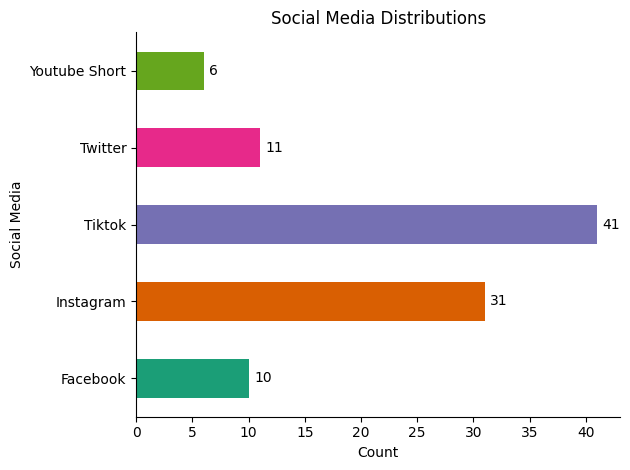

In [ ]:
# Create grouped data
counts = df.groupby('social_media').size()

# Plot
ax = counts.plot(kind='barh', color=sns.color_palette('Dark2'))

# Style
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Count')
plt.ylabel('Social Media')
plt.title("Social Media Distributions")

# Add value labels
for i, v in enumerate(counts):
    ax.text(v + 0.5, i, str(v), va='center')  # `v + 0.5` adjusts position; tweak if needed

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Social Media vs Content Format')

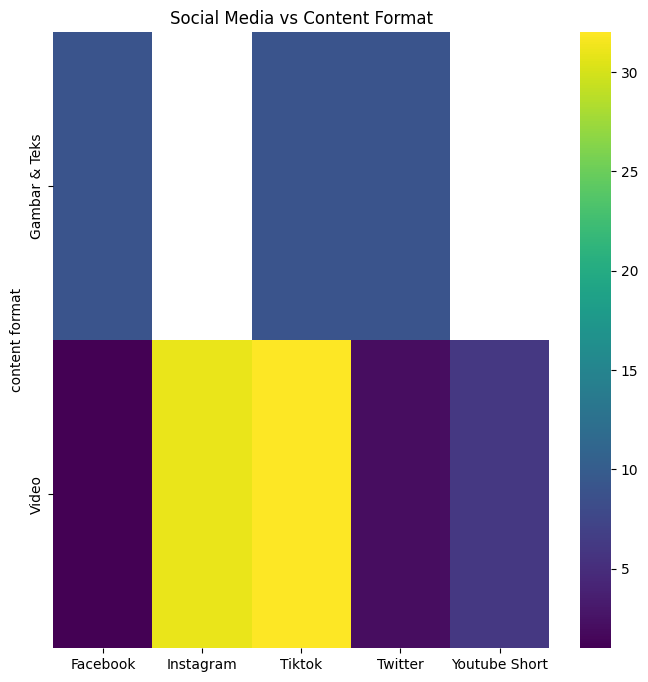

In [ ]:
# @title social_media vs content_format

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['content_format'].value_counts()
    for x_label, grp in df.groupby('social_media')
})
sns.heatmap(df_2dhist, cmap='viridis')
_ = plt.ylabel('content format')
plt.title("Social Media vs Content Format")

- We analyzed 100 Mova promotion posts across 5 platforms: Facebook, Instagram, TikTok, Twitter, and YouTube Shorts. As shown in the first chart, the distribution is uneven. TikTok (41%) and Instagram (31%) dominate, while YouTube Shorts (6%), Twitter (11%), and Facebook (10%) are less represented. This reflects the abundance of Mova-related content on these platforms, which led to a naturally higher sampling from them.
- Platforms show a clear preference for specific content formats:
  - Instagram, TikTok, and YouTube Shorts are heavily skewed toward video
content, aligning with their platform strengths.
  - Facebook and Twitter display a more balanced mix of video and text/image- based content.

Text(0.5, 1.0, 'Average Rating by Platform and Content Format')

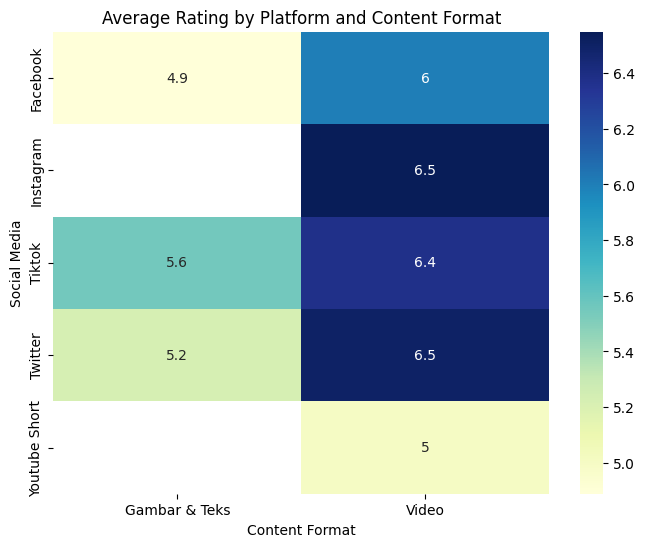

In [ ]:
pivot = df.pivot_table(
    index='social_media',
    columns='content_format',
    values='rating',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.xlabel("Content Format")
plt.ylabel("Social Media")
plt.title("Average Rating by Platform and Content Format")


Text(0.5, 1.0, 'Average Views by Platform and Content Format')

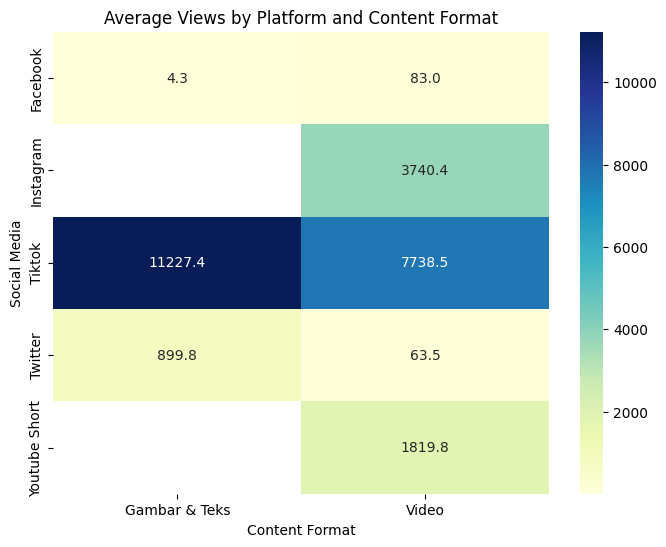

In [ ]:
pivot = df.pivot_table(
    index='social_media',
    columns='content_format',
    values='impressions_views',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))  # Adjust height and width as needed
# sns.heatmap(pivot, annot=True, cmap='YlGnBu')
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.xlabel("Content Format")
plt.ylabel("Social Media")
plt.title("Average Views by Platform and Content Format")

- Facebook does not publicly display  the number of impressions or views for posts. The value shown for Facebook is based on like counts, which are not directly
comparable to view counts on other platforms and should be interpreted with
caution.
- TikTok shows a significantly higher average number of views for both content
formats (image/text and video), indicating strong visibility on the platform. Instagram follows, with video content averaging around 3.7k views, reflecting
its strong engagement, particularly with visual formats.
- The content ratings were subjectively assigned by data collectors (Talitha &
Bunga), which introduces potential bias. However, a trend is clear: video content
tends to receive higher ratings than image/text content across all platforms. This
suggests that video is perceived as more engaging or appealing for promotional
content.
- Instagram, TikTok, and Twitter videos received the highest average ratings, indicating that these platforms are especially effective for distributing video-based
promotional content. Conversely, Youtube Shorts, despite being a video-first
platform, received lower ratings, which may be due to limited sampling or
differences in content quality

Text(0.5, 1.0, 'Number of Mova-Related Posts Across Social Media Platforms')

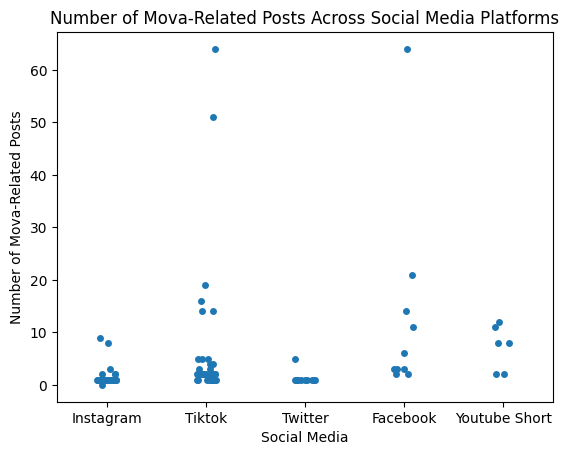

In [ ]:
sns.stripplot(data=df, x='social_media', y='number_mova_related_post', jitter=True)

plt.ylabel("Number of Mova-Related Posts")
plt.xlabel("Social Media")
plt.title("Number of Mova-Related Posts Across Social Media Platforms")


- TikTok and Facebook show a wide distribution in the number of Mova-related
posts per account, ranging from 1 post to over 60 posts. This suggests that some
users are highly active in promoting Mova, while others are one-time contributors.
- On the other hand, Instagram, TikTok, and Twitter users predominantly post
only once about Mova. This pattern indicates that many of these posts may be
commissioned content or part of single collaborations rather than organic or
ongoing promotion.
- Facebook stands out as a platform where some users post Mova content
repeatedly, likely driven by participation in the Mova affiliate program. These
users may be part of dedicated communities aiming to grow the brand’s reach by
frequently sharing Mova content, possibly to attract new users or other affiliates.

<ipython-input-94-3754029753>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='impressions_views', y='social_media', inner='stick', palette='Dark2', cut=0)


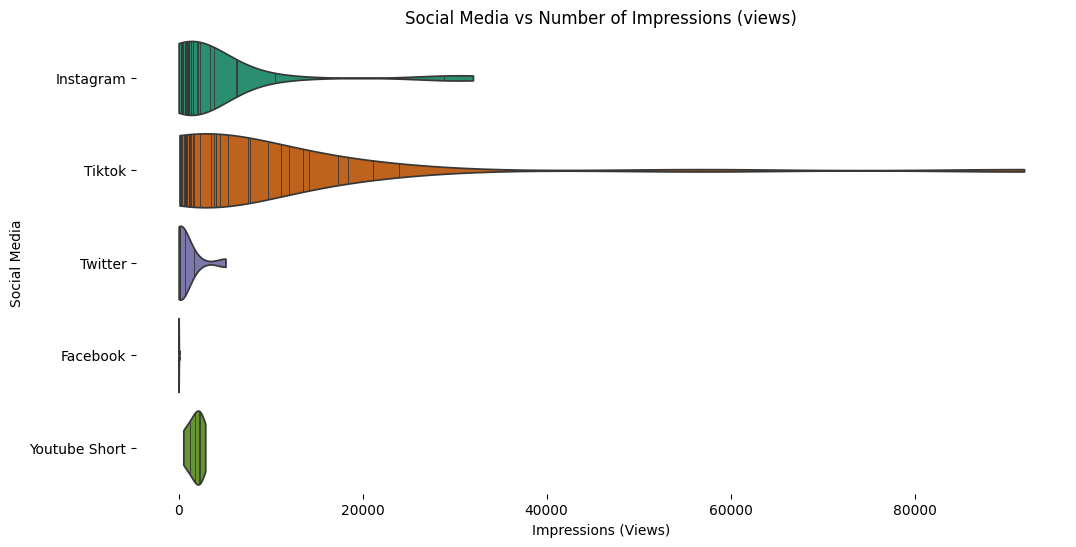

In [ ]:
# @title social_media vs impressions_views

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['social_media'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='impressions_views', y='social_media', inner='stick', palette='Dark2', cut=0)
plt.xlabel("Impressions (Views)")
plt.ylabel("Social Media")
plt.title("Social Media vs Number of Impressions (views)")
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
(df['impressions_views'] < 0).sum()

np.int64(0)

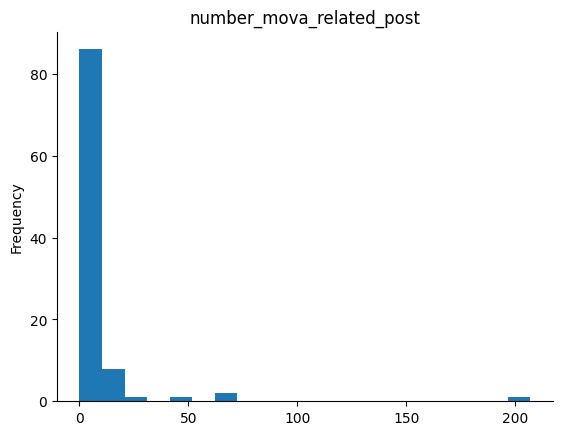

In [ ]:
# @title number_mova_related_post

from matplotlib import pyplot as plt
df['number_mova_related_post'].plot(kind='hist', bins=20, title='number_mova_related_post')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
!pip install wordcloud

## Promotional language analysis

In [ ]:
from wordcloud import WordCloud

In [ ]:
text = ' '.join(df['promotional_language'].dropna().astype(str).tolist())

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Add your custom words here
stopwords = set(STOPWORDS)
stopwords.update(['mova', 'banget'])

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords
).generate(text)


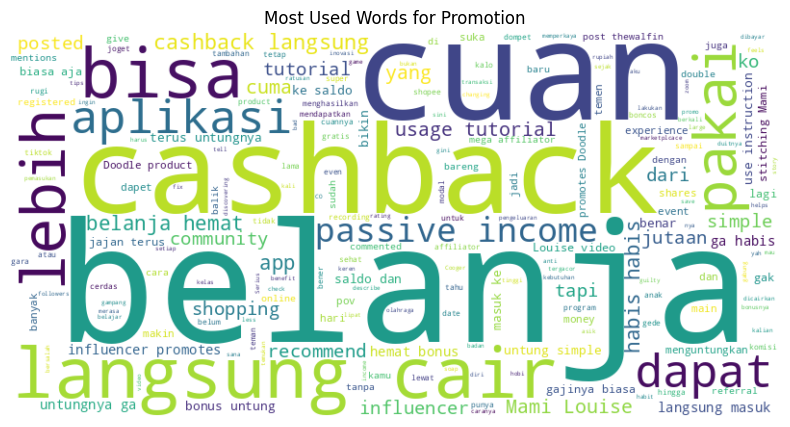

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Used Words for Promotion")
plt.show()

- The most frequently used words in Mova promotions include “Cuan” (profit), “Cashback”, “Belanja” (shopping), “Langsung Cair” (instant disbursement), and “Passive Income”. These terms reflect the financial incentives and
convenience emphasized in promotional content.
- The strong presence of these keywords suggests that monetary benefits are the
primary appeal strategy. Users are more likely to be engaged by content that
highlights earning potential, immediate rewards, and spending perks.
- The promotional language leans heavily into practicality and ease of use, with
supporting words like “pakai” (use), “bisa” (can), “tutorial,” and “mudah”
(easy). This reinforces the message that Mova is accessible and user-friendly for
a wide audience.
- The appearance of terms like “influencer,” “rekomendasi” (recommendation), and “tutorial” implies that influencer marketing and how-to content are common
formats used to build trust and guide new users.